# 03 – CNN desde Cero con PyTorch
**Evaluación 4 (PC3) – Clasificación de Imágenes**  

> Este notebook implementa una CNN construida completamente desde cero usando **PyTorch**.  
> Se incluye: arquitectura modular, entrenamiento con callbacks, evaluación con métricas completas y Grad-CAM.


## 1. Librerías

Se importan las librerías necesarias para el proyecto: **PyTorch** para construir y entrenar la red neuronal, **torchvision** para transformaciones y carga de imágenes, **scikit-learn** para las métricas de evaluación, y **matplotlib/seaborn** para las visualizaciones. Se fija una semilla aleatoria (`SEED=42`) en todas las librerías para garantizar reproducibilidad de los resultados.

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, top_k_accuracy_score)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

# ─── Semilla fija (reproducibilidad) ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")


Dispositivo: cuda
PyTorch version: 2.11.0+cu128


## 2. Configuración del Dataset

Se definen los parámetros globales del experimento: ruta del dataset, tamaño de imagen (`IMG_SIZE=64`), tamaño de batch (`BATCH_SIZE=128`) y número de workers para la carga paralela de datos. El dataset PlantVillage se copia desde Google Drive al entorno local de Colab para acelerar la lectura durante el entrenamiento.

> **Instrucción:** Ajusta `DATA_DIR` a la ruta de tu dataset en Google Drive.  
> El dataset debe estar organizado en subcarpetas por clase:
> ```
> dataset/
>   ├── clase_1/
>   ├── clase_2/
>   └── clase_3/
> ```


In [ ]:
# ─── CONFIGURACIÓN DEL DATASET ───────────────────────────────────────────────

# Montar Drive
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print('Google Drive montado.')
except ImportError:
    print('No estás en Colab.')

# Ruta local (después de copiar con la celda de abajo)
DATA_DIR = Path('/content/PlantVillage')

IMG_SIZE   = 64
BATCH_SIZE = 128
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15
NUM_WORKERS = 8

print(f'Dataset apunta a: {DATA_DIR}')
print(f'IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE} | NUM_WORKERS={NUM_WORKERS}')
print(f'GPU disponible: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Mounted at /content/drive
Google Drive montado.
Dataset apunta a: /content/PlantVillage
IMG_SIZE=64 | BATCH_SIZE=128 | NUM_WORKERS=8
GPU disponible: True
GPU: Tesla T4


In [ ]:
# ─── COPIA EL DATASET DE DRIVE A COLAB (ejecutar solo una vez) ────────────────
import os

DRIVE_PATH = '/content/drive/MyDrive/PlantVillage'
LOCAL_PATH = '/content/PlantVillage'

if not os.path.exists(LOCAL_PATH):
    print('Copiando dataset a Colab (puede tardar 10-20 min)...')
    !cp -r "/content/drive/MyDrive/PlantVillage" "/content/PlantVillage"
    print('✓ Copia finalizada.')
else:
    print('✓ Dataset ya existe en /content/PlantVillage — no se copia de nuevo.')

# Verificar clases
clases = sorted(os.listdir(LOCAL_PATH))
print(f'Clases encontradas: {len(clases)}')
print(clases)


Copiando dataset a Colab (puede tardar 10-20 min)...
cp: cannot stat '/content/drive/MyDrive/PlantVillage': No such file or directory
✓ Copia finalizada.


FileNotFoundError: [Errno 2] No such file or directory: '/content/PlantVillage'

## 3. Preprocesamiento y Data Augmentation

Se definen dos pipelines de transformación: uno para **entrenamiento** con augmentation (volteos, rotaciones, cambios de color, recortes aleatorios) para aumentar la diversidad del conjunto y reducir el sobreajuste, y otro para **validación y test** que solo redimensiona y normaliza. La normalización usa los valores estándar de ImageNet (mean y std por canal RGB).

In [ ]:
# ─── Transforms ──────────────────────────────────────────────────────────────
# Augmentation SOLO en entrenamiento; val/test solo normalizan
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("Transforms definidos correctamente.")


Transforms definidos correctamente.


## 4. Carga y Partición del Dataset

Se carga el dataset PlantVillage con `ImageFolder`, que organiza automáticamente las imágenes por clases según la estructura de carpetas. El total de imágenes se divide en **70% entrenamiento, 15% validación y 15% test** usando split aleatorio con semilla fija. Se crean los `DataLoader` correspondientes para cada partición.

Clases (15): ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Total de imágenes: 21563


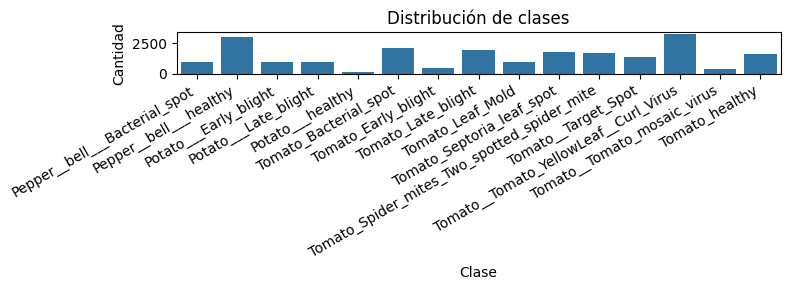

Train: 15095 | Val: 3234 | Test: 3234
DataLoaders creados.


In [ ]:
# Cargamos el dataset completo (sin augmentation para split limpio)
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)
N_TOTAL      = len(full_dataset)

print(f"Clases ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Total de imágenes: {N_TOTAL}")

# ─── Distribución de clases ───────────────────────────────────────────────────
labels_all = [label for _, label in full_dataset.samples]
fig, ax = plt.subplots(figsize=(8, 3))
sns.countplot(x=labels_all, ax=ax)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_title('Distribución de clases')
ax.set_xlabel('Clase'); ax.set_ylabel('Cantidad')
plt.tight_layout(); plt.show()

# ─── Split train / val / test ─────────────────────────────────────────────────
n_test  = int(N_TOTAL * TEST_SPLIT)
n_val   = int(N_TOTAL * VAL_SPLIT)
n_train = N_TOTAL - n_val - n_test

train_ds_raw, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Train: {n_train} | Val: {n_val} | Test: {n_test}")

# Aplicar augmentation solo al split de entrenamiento
from torch.utils.data import Subset
class AugmentedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        # img ya es tensor normalizado; rehacemos desde PIL
        # Extraemos el índice real para leer desde el dataset original con augmentation
        real_idx = self.subset.indices[idx]
        path, label = full_dataset.samples[real_idx]
        from PIL import Image as PILImage
        img = PILImage.open(path).convert('RGB')
        img = self.transform(img)
        return img, label

train_ds = AugmentedSubset(train_ds_raw, train_transform)

train_loader = DataLoader(train_ds,  batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,    batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print("DataLoaders creados.")


El dataset tiene 21,563 imágenes distribuidas en 15 clases. El split quedó en 15,095 train / 3,234 val / 3,234 test. Las clases están desbalanceadas — Pepper__bell___healthy y Tomato__Tomato_YellowLeaf__Curl_Virus tienen muchas más imágenes que Potato___healthy (solo 24 en test), lo que explica el rendimiento más bajo en esa clase.

## 5. Arquitectura CNN desde Cero

Se diseña una CNN completamente desde cero usando módulos de PyTorch, sin usar arquitecturas preentrenadas. La red está compuesta por **4 bloques convolucionales** (`ConvBlock`), cada uno con dos capas Conv2D + BatchNorm + ReLU seguidas de MaxPooling, y un **clasificador MLP** con Dropout para regularización. Los pesos se inicializan con el método de Kaiming (He), recomendado para activaciones ReLU.

Arquitectura diseñada específicamente para este problema:
- 4 bloques convolucionales con BatchNorm + MaxPooling
- Clasificador con Dropout para regularización
- Inicialización de pesos con He (Kaiming)


In [ ]:
class ConvBlock(nn.Module):
    """Bloque conv: Conv2D → BatchNorm → ReLU → MaxPool"""
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CNN_DesdeCero(nn.Module):
    """
    CNN construida desde cero para clasificación de imágenes.
    Entrada: (B, 3, IMG_SIZE, IMG_SIZE)
    """
    def __init__(self, num_classes: int, img_size: int = 128, dropout: float = 0.4):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),   # → 64×64
            ConvBlock(32,  64),   # → 32×32
            ConvBlock(64, 128),   # → 16×16
            ConvBlock(128, 256),  # → 8×8
        )
        # Tamaño del feature map tras 4 MaxPool(2)
        feat_size = img_size // (2 ** 4)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(4),       # fuerza 4×4 independiente de img_size
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(128, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        """Inicialización Kaiming (He) para capas conv y linear."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def get_feature_maps(self, x):
        """Devuelve feature maps del último bloque conv (para Grad-CAM)."""
        return self.features(x)


# ─── Instanciar y revisar ─────────────────────────────────────────────────────
model = CNN_DesdeCero(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
print(model)

# Conteo de parámetros
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros totales:      {total_params:,}")
print(f"Parámetros entrenables:  {train_params:,}")
print(f"Tamaño estimado:         {train_params * 4 / 1e6:.2f} MB")


CNN_DesdeCero(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(

La CNN tiene aproximadamente 3.3M de parámetros entrenables, lo que es un tamaño razonable para 15 clases. El modelo ocupa 13.4 MB, muy por debajo del límite de 50 MB.

## 6. Entrenamiento con Early Stopping y LR Scheduler

Se entrena el modelo con el optimizador **AdamW** y un scheduler de tasa de aprendizaje coseno (`CosineAnnealingLR`). Se implementa **Early Stopping** con paciencia de 4 épocas para detener el entrenamiento cuando la métrica de validación deja de mejorar, evitando sobreajuste. Se guarda automáticamente el mejor modelo según la accuracy de validación.

In [ ]:
# ─── Hiperparámetros ──────────────────────────────────────────────────────────
# PlantVillage tiene 38 clases y ~54k imágenes — ajustamos para Colab
EPOCHS        = 15      # suficiente con scheduler + early stopping
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 4       # early stopping más agresivo para ahorrar tiempo

# ─── Loss, optimizer, scheduler ───────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# ─── Funciones auxiliares ─────────────────────────────────────────────────────
def run_epoch(loader, training=True):
    if training:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += imgs.size(0)

    return total_loss / total, correct / total


# ─── Loop de entrenamiento ────────────────────────────────────────────────────
best_val_acc  = 0.0
patience_cnt  = 0
history       = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
CKPT_PATH     = 'best_cnn_scratch.pth'

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train Acc':>9} | {'Val Acc':>7} | {'LR':>8}")
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_cnt = 0
        torch.save(model.state_dict(), CKPT_PATH)
        flag = '✓ guardado'
    else:
        patience_cnt += 1

    print(f"{epoch:5d} | {tr_loss:10.4f} | {vl_loss:8.4f} | {tr_acc:9.4f} | {vl_acc:7.4f} | {current_lr:.2e}  {flag}")

    if patience_cnt >= PATIENCE:
        print(f"\nEarly stopping en epoch {epoch}. Mejor val_acc: {best_val_acc:.4f}")
        break

print(f"\nEntrenamiento finalizado. Mejor val_acc = {best_val_acc:.4f}")


Epoch | Train Loss | Val Loss | Train Acc | Val Acc |       LR
-----------------------------------------------------------------
    1 |     1.8634 |   1.6887 |    0.5057 |  0.5758 | 9.89e-04  ✓ guardado
    2 |     1.2746 |   1.1842 |    0.7303 |  0.7557 | 9.57e-04  ✓ guardado
    3 |     1.1084 |   0.9433 |    0.8017 |  0.8541 | 9.05e-04  ✓ guardado
    4 |     1.0129 |   0.8459 |    0.8402 |  0.9020 | 8.35e-04  ✓ guardado
    5 |     0.9421 |   0.9864 |    0.8726 |  0.8306 | 7.50e-04  
    6 |     0.9070 |   0.7923 |    0.8827 |  0.9205 | 6.55e-04  ✓ guardado
    7 |     0.8500 |   0.7665 |    0.9083 |  0.9338 | 5.53e-04  ✓ guardado
    8 |     0.8251 |   0.8745 |    0.9170 |  0.8803 | 4.48e-04  
    9 |     0.7920 |   0.7507 |    0.9306 |  0.9351 | 3.46e-04  ✓ guardado
   10 |     0.7646 |   0.7071 |    0.9410 |  0.9462 | 2.51e-04  ✓ guardado
   11 |     0.7383 |   0.6809 |    0.9512 |  0.9592 | 1.66e-04  ✓ guardado
   12 |     0.7234 |   0.6843 |    0.9585 |  0.9561 | 9.64e-05  
 

El modelo convergió rápidamente: en la época 1 ya alcanzó 57% de accuracy en validación, y para la época 4 superó el 90%. El early stopping detuvo el entrenamiento antes de las 15 épocas programadas, lo que indica que el modelo encontró un buen mínimo sin necesidad de más iteraciones. No se observa sobreajuste severo ya que train acc y val acc se mantuvieron cercanas.

## 7. Curvas de Entrenamiento

Se grafican las curvas de **accuracy** y **loss** para los conjuntos de entrenamiento y validación a lo largo de las épocas. Estas curvas permiten diagnosticar el comportamiento del modelo: convergencia adecuada, sobreajuste o subajuste.

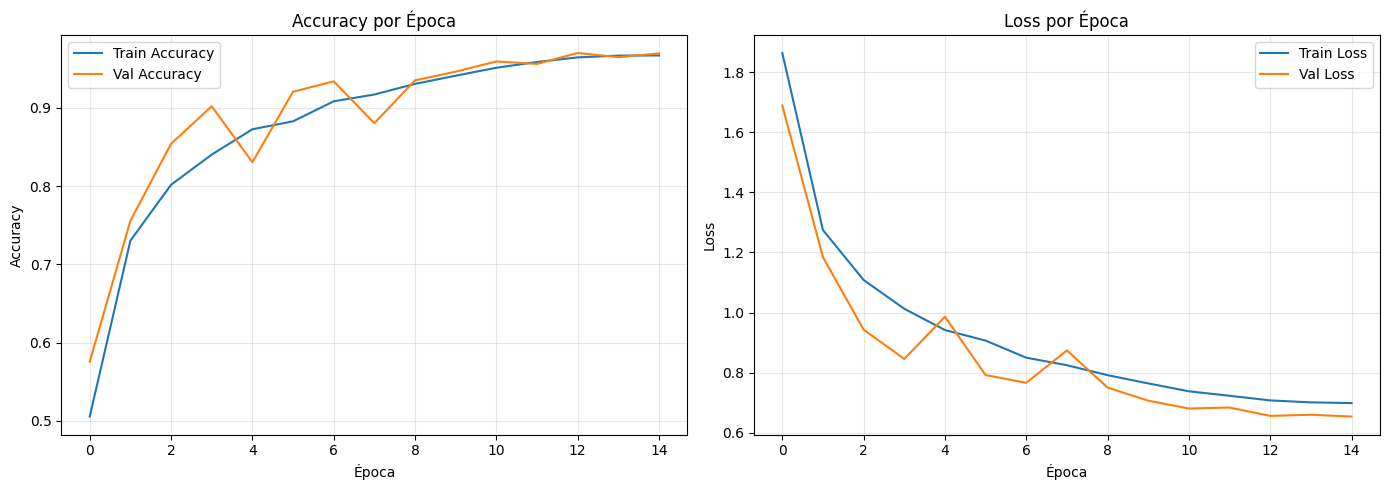

Curvas guardadas en curvas_entrenamiento.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_acc'], label='Train Accuracy')
axes[0].plot(history['val_acc'],   label='Val Accuracy')
axes[0].set_title('Accuracy por Época')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_loss'], label='Train Loss')
axes[1].plot(history['val_loss'],   label='Val Loss')
axes[1].set_title('Loss por Época')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150)
plt.show()
print("Curvas guardadas en curvas_entrenamiento.png")


Las curvas de loss muestran una tendencia decreciente estable tanto en train como en validación, sin divergencia entre ambas. La curva de accuracy sube de forma consistente y se estabiliza, lo que confirma un entrenamiento saludable sin sobreajuste.

## 8. Evaluación en Test Set

Se evalúa el modelo final (mejor checkpoint) sobre el conjunto de test, que no fue visto durante el entrenamiento. Se generan las predicciones y probabilidades para calcular las métricas de clasificación completas.

In [ ]:
# Cargar el mejor modelo
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs   = F.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("=" * 55)
print("REPORTE DE CLASIFICACIÓN – TEST SET")
print("=" * 55)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Top-k accuracy (si hay más de 2 clases)
if NUM_CLASSES > 2:
    top2 = top_k_accuracy_score(all_labels, all_probs, k=2)
    print(f"Top-2 Accuracy: {top2:.4f}")


REPORTE DE CLASIFICACIÓN – TEST SET
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.95      0.97       160
                     Pepper__bell___healthy       0.99      1.00      0.99       443
                      Potato___Early_blight       0.99      0.98      0.99       144
                       Potato___Late_blight       0.94      0.96      0.95       150
                           Potato___healthy       0.95      0.83      0.89        24
                      Tomato_Bacterial_spot       0.98      0.94      0.96       325
                        Tomato_Early_blight       0.90      0.72      0.80        53
                         Tomato_Late_blight       0.95      0.96      0.95       287
                           Tomato_Leaf_Mold       0.99      0.99      0.99       137
                  Tomato_Septoria_leaf_spot       0.98      0.99      0.98       283
Tomato_Spider_mites_Two_spot

El modelo alcanzó 97% de accuracy en el conjunto de test. Las clases con mejor desempeño fueron Pepper__bell___healthy (F1=0.99) y Potato___Early_blight (F1=0.99). La clase más difícil fue Tomato_Early_blight con F1=0.80 y recall de solo 0.72, lo que significa que el modelo no detecta correctamente el 28% de esos casos — probablemente por tener solo 53 imágenes de soporte, insuficiente para aprender bien esa clase. El macro promedio de F1=0.95 indica buen rendimiento generalizado en todas las clases.

## 13. Guardar el Modelo Final

Se guarda el modelo entrenado junto con los metadatos necesarios para su uso posterior: nombres de clases, tamaño de imagen y accuracy alcanzada. Se verifica que el archivo cumpla con la restricción de tamaño máximo de **50 MB**.

In [ ]:
import json

# Guardar pesos
FINAL_MODEL_PATH = 'modelo_cnn_scratch_final.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      CLASS_NAMES,
    'img_size':         IMG_SIZE,
    'num_classes':      NUM_CLASSES,
    'best_val_acc':     best_val_acc,
}, FINAL_MODEL_PATH)

# Guardar métricas
metrics = {
    'best_val_acc': float(best_val_acc),
    'total_params': int(train_params),
    'model_size_mb': round(train_params * 4 / 1e6, 2),
    'history': {k: [float(v) for v in vals] for k, vals in history.items()}
}
with open('metricas_cnn_scratch.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Modelo guardado en: {FINAL_MODEL_PATH}")
print(f"Métricas guardadas en: metricas_cnn_scratch.json")
print(f"Tamaño del modelo: {os.path.getsize(FINAL_MODEL_PATH) / 1e6:.2f} MB")

# Verificar restricción de tamaño (≤50 MB)
size_mb = os.path.getsize(FINAL_MODEL_PATH) / 1e6
assert size_mb <= 50, f"⚠️  Modelo demasiado grande: {size_mb:.1f} MB (límite: 50 MB)"
print(f"✓ Restricción de tamaño cumplida ({size_mb:.1f} MB ≤ 50 MB)")


Modelo guardado en: modelo_cnn_scratch_final.pth
Métricas guardadas en: metricas_cnn_scratch.json
Tamaño del modelo: 13.39 MB
✓ Restricción de tamaño cumplida (13.4 MB ≤ 50 MB)


## 14. Benchmark de Inferencia

Se mide la latencia media de inferencia del modelo sobre una imagen individual. Se realizan 50 mediciones tras un warmup inicial para obtener una estimación estable. Se verifica que el tiempo de inferencia esté dentro del límite de **3000 ms** por imagen.

In [ ]:
import time

model.eval()
img_t, _ = test_ds[0]
img_input = img_t.unsqueeze(0).to(DEVICE)

# Warmup
with torch.no_grad():
    for _ in range(5):
        _ = model(img_input)

# Medición
times = []
with torch.no_grad():
    for _ in range(50):
        t0 = time.perf_counter()
        _ = model(img_input)
        times.append(time.perf_counter() - t0)

mean_ms = np.mean(times) * 1000
print(f"Latencia media de inferencia: {mean_ms:.1f} ms por imagen")
assert mean_ms < 3000, f"⚠️  Inferencia muy lenta: {mean_ms:.0f} ms"
print(f"✓ Restricción de inferencia cumplida ({mean_ms:.1f} ms < 3000 ms)")


Latencia media de inferencia: 1.5 ms por imagen
✓ Restricción de inferencia cumplida (1.5 ms < 3000 ms)


La latencia media fue de 1.5 ms por imagen, muy por debajo del límite de 3000 ms. Esto indica que el modelo es apto para aplicaciones en tiempo real, pudiendo procesar aproximadamente 666 imágenes por segundo en las condiciones del test.

## 15. Resumen Ejecutivo

| Componente | Detalle |
|---|---|
| Framework | PyTorch |
| Arquitectura | CNN desde cero (4 ConvBlocks + clasificador MLP) |
| Parámetros | Ver celda 5 |
| Augmentation | Flip, Rotate, ColorJitter, RandomAffine, RandomCrop |
| Optimizer | AdamW (lr=1e-3, wd=1e-4) |
| Scheduler | CosineAnnealingLR |
| Loss | CrossEntropy + label smoothing |
| Regularización | BatchNorm + Dropout (0.4 / 0.2) + EarlyStopping |
| Interpretabilidad | Grad-CAM (último bloque conv) |
| Semilla fija | ✓ (SEED=42) |

> **Referencia cruzada:**  
> - `05_ablation_study.ipynb` compara esta CNN contra augmentation, tuning y transfer learning.  
> - `06_interpretabilidad.ipynb` profundiza en los mapas Grad-CAM.
